# 27. Colab GPU Smoke Test

Notebook de verificación rápida del pipeline `qml4var` sobre la GPU de Google Colab,
antes de lanzar experimentos al servidor de GPU dedicado.

**Qué comprueba:**
- CUDA disponible y visible por PyTorch.
- Instalación correcta de PennyLane.
- Construcción del ansatz `hardware_efficient_ansatz` y creación del `workflow_cfg`.
- Entrenamiento **supervisado** y **no supervisado** con 3 strikes × 3 repeticiones.
- Cálculo de precio por Fourier y visualización de resultados.

**Arquitectura de aceleración:**
- Circuitos: `default.qubit` + `backprop` (necesario para derivadas de segundo orden del término PDF).
- Batching: `qml.vmap` evalúa todos los puntos de entrenamiento en una sola llamada al circuito (elimina el bucle Python por muestra).
- GPU: `torch_device="cuda"` — todas las operaciones de tensores PyTorch (Adam, loss, gradientes) corren en CUDA.

---

**Antes de ejecutar:** asegúrate de que el entorno de ejecución de Colab
tiene acelerador GPU activo (`Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU`).

## 0. Verificar GPU del entorno Colab

In [1]:
import subprocess

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
else:
    print("[WARN] nvidia-smi no disponible. Verifica que el entorno tiene GPU activa.")
    print(result.stderr)

Sun Mar 22 18:43:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Instalar dependencias

El pipeline usa `default.qubit` + `backprop` + `qml.vmap` para batching.
La GPU acelera las operaciones de tensores PyTorch vía `torch_device="cuda"`.
`pennylane-lightning[gpu]` **no es necesario**.

In [2]:
import sys

!{sys.executable} -m pip install --quiet \
    "pennylane>=0.38" \
    "pennylane-lightning>=0.38" \
    numpy

print("Instalación completada.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 103.8 MB/s eta 0:00:0000:0100:01
Instalación completada.


## 2. Montar el repositorio

Dos opciones; ejecuta **sólo una** de las dos celdas siguientes.

### Opción A — Google Drive (recomendada si el repo está en Drive)

In [3]:
import os

from google.colab import drive

drive.mount("/content/drive")

# Ajusta la ruta si el repo está en otro lugar de tu Drive
REPO_ROOT = "/content/drive/MyDrive/CodeTFM"

sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
print("REPO_ROOT:", REPO_ROOT)


Mounted at /content/drive
REPO_ROOT: /content/drive/MyDrive/CodeTFM


### Opción B — Clonar desde GitHub

In [4]:
# Sustituye la URL por la de tu repositorio
# !git clone https://github.com/TU_USUARIO/CodeTFM.git /content/CodeTFM

# REPO_ROOT = "/content/CodeTFM"
# import sys, os
# sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
# print("REPO_ROOT:", REPO_ROOT)


## 3. Imports y verificación de GPU en PyTorch

In [5]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
import torch

from finance import (
    bs_put_price,
    estimate_price_from_trained_pqc,
)
from qml4var.adam import adam_optimizer_loop
from qml4var.architectures import (
    hardware_efficient_ansatz,
    init_weights,
    normalize_data,
)
from qml4var.data_utils import (
    empirical_cdf,
    simulate_black_scholes_data_rescaled,
)
from qml4var.losses import torch_gradient
from qml4var.workflows import (
    qdml_loss_workflow,
    unsupervised_qdml_loss_workflow,
    workflow_for_cdf,
)

# --- Verificación CUDA ---
TORCH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch version    : {torch.__version__}")
print(f"pennylane version: {qml.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name         : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version     : {torch.version.cuda}")
print(f"TORCH_DEVICE     : {TORCH_DEVICE}")

if TORCH_DEVICE == "cpu":
    print()
    print("[WARN] No se detectó GPU. El test continúa en CPU, pero verifica")
    print("       que el entorno de Colab tiene acelerador GPU activado.")


torch version    : 2.10.0+cu128
pennylane version: 0.44.1
CUDA available   : True
GPU name         : Tesla T4
CUDA version     : 12.8
TORCH_DEVICE     : cuda


## 4. Configuración del experimento

In [6]:
# Black-Scholes
S0, r, sigma, T = 100.0, 0.10, 0.25, 1.0

STRIKES = [90, 100, 110]   # ITM, ATM, OTM
REPETITIONS = 3                # repeticiones por (modo, strike)
BASE_SEED = 2026

TRAIN_INTERVAL = (-2.0 * np.pi, 2.0 * np.pi)
ENCODING_INTERVAL = (-1.0 * np.pi, 1.0 * np.pi)
FEATURES_NUMBER = 1

SMOKE_CFG = {
    "n_qubits_by_feature": 2,
    "n_layers": 2,
    "n_train": 500,
    "n_test": 100,
    "epochs": 10,
    "learning_rate": 0.05,
    "beta1": 0.9,
    "beta2": 0.999,
    "tolerance": 1.0e-8,
    "n_counts_tolerance": 999,
    "print_step": 5,
    "empirical_shift": -0.5,
    "loss_weights_sup": [0.9, 0.1],
    "loss_weights_unsup": [0.2, 0.8],
}

K_TERMS = 8
GRID_POINTS_F = 512

total_runs = 2 * len(STRIKES) * REPETITIONS
print(f"Strikes      : {STRIKES}")
print(f"Repeticiones : {REPETITIONS}")
print(f"Runs totales : {total_runs}  (2 modos × {len(STRIKES)} strikes × {REPETITIONS} reps)")
print(f"Config       : {SMOKE_CFG}")

Strikes      : [90, 100, 110]
Repeticiones : 3
Runs totales : 18  (2 modos × 3 strikes × 3 reps)
Config       : {'n_qubits_by_feature': 2, 'n_layers': 2, 'n_train': 500, 'n_test': 100, 'epochs': 10, 'learning_rate': 0.05, 'beta1': 0.9, 'beta2': 0.999, 'tolerance': 1e-08, 'n_counts_tolerance': 999, 'print_step': 5, 'empirical_shift': -0.5, 'loss_weights_sup': [0.9, 0.1], 'loss_weights_unsup': [0.2, 0.8]}


## 5. Construir circuito y `workflow_cfg`

In [7]:
base_frecuency, shift_feature = normalize_data(
    [TRAIN_INTERVAL[0]] * FEATURES_NUMBER,
    [TRAIN_INTERVAL[1]] * FEATURES_NUMBER,
    [ENCODING_INTERVAL[0]] * FEATURES_NUMBER,
    [ENCODING_INTERVAL[1]] * FEATURES_NUMBER,
)

circuit_fn, weights_names, features_names = hardware_efficient_ansatz(
    features_number=FEATURES_NUMBER,
    n_qubits_by_feature=SMOKE_CFG["n_qubits_by_feature"],
    n_layers=SMOKE_CFG["n_layers"],
    base_frecuency=list(base_frecuency),
    shift_feature=list(shift_feature),
)

workflow_cfg = {
    "circuit_fn": circuit_fn,
    "weights_names": weights_names,
    "features_names": features_names,
    "torch_device": TORCH_DEVICE,
    "minval": [TRAIN_INTERVAL[0]],
    "maxval": [TRAIN_INTERVAL[1]],
    "points": 60,
}

print(f"Qubits totales : {SMOKE_CFG['n_qubits_by_feature'] * FEATURES_NUMBER}")
print(f"Parámetros     : {len(weights_names)}")
print(f"torch_device   : {TORCH_DEVICE}")

[hardware_efficient_ansatz] device=default.qubit  diff_method=backprop  wires=2
Qubits totales : 2
Parámetros     : 4
torch_device   : cuda


## 6. Funciones auxiliares

In [8]:
def _optimizer_kwargs():
    return dict(
        epochs=SMOKE_CFG["epochs"],
        learning_rate=SMOKE_CFG["learning_rate"],
        beta1=SMOKE_CFG["beta1"],
        beta2=SMOKE_CFG["beta2"],
        tolerance=SMOKE_CFG["tolerance"],
        n_counts_tolerance=SMOKE_CFG["n_counts_tolerance"],
        print_step=SMOKE_CFG["print_step"],
    )


def train_supervised(u_train, wf_cfg, weights_names):
    y_train = empirical_cdf(u_train).reshape((-1, 1)) - 0.5

    def loss_fn(w):
        return qdml_loss_workflow(
            w, u_train, y_train, dask_client=None,
            loss_weights=SMOKE_CFG["loss_weights_sup"], **wf_cfg,
        )

    def _inner_loss(w_, x_, y_):
        return qdml_loss_workflow(
            w_, x_, y_, dask_client=None,
            loss_weights=SMOKE_CFG["loss_weights_sup"], **wf_cfg,
        )

    def grad_fn(w, x, y):
        return torch_gradient(w, x, y, _inner_loss)

    return adam_optimizer_loop(
        weights_dict=init_weights(weights_names),
        loss_function=loss_fn,
        metric_function=None,
        gradient_function=grad_fn,
        batch_generator=[(u_train, y_train)],
        initial_time=0,
        **_optimizer_kwargs(),
    )


def train_unsupervised(u_train, wf_cfg, weights_names):
    dummy_y = np.zeros((u_train.shape[0], 1))

    def loss_fn(w):
        return unsupervised_qdml_loss_workflow(
            w, u_train, dask_client=None,
            empirical_shift=SMOKE_CFG["empirical_shift"],
            loss_weights=SMOKE_CFG["loss_weights_unsup"], **wf_cfg,
        )

    def _inner_loss(w_, x_, y_):
        return unsupervised_qdml_loss_workflow(
            w_, x_, dask_client=None,
            empirical_shift=SMOKE_CFG["empirical_shift"],
            loss_weights=SMOKE_CFG["loss_weights_unsup"], **wf_cfg,
        )

    def grad_fn(w, x, y):
        return torch_gradient(w, x, y, _inner_loss)

    return adam_optimizer_loop(
        weights_dict=init_weights(weights_names),
        loss_function=loss_fn,
        metric_function=None,
        gradient_function=grad_fn,
        batch_generator=[(u_train, dummy_y)],
        initial_time=0,
        **_optimizer_kwargs(),
    )


print("Funciones de entrenamiento definidas.")


Funciones de entrenamiento definidas.


## 7. Experimento principal — loop sobre modos, strikes y repeticiones

In [ ]:
results = []
saved_weights = {}  # {(mode_name, K_): [weights_rep1, ...]}
global_t0 = perf_counter()
run_idx = 0
total_runs = 2 * len(STRIKES) * REPETITIONS
n_total = SMOKE_CFG["n_train"] + SMOKE_CFG["n_test"]

for mode_name in ["supervised", "unsupervised"]:
    for K_ in STRIKES:
        theor_price = bs_put_price(S0, K_, r, sigma, T)
        for rep in range(1, REPETITIONS + 1):
            run_idx += 1
            seed = BASE_SEED + 100_000 * rep + 1_000 * int(K_)

            _, u_all, x_min, x_max = simulate_black_scholes_data_rescaled(
                S0_=S0, r_=r, T_=T, sigma_=sigma, K_=K_, n_points=n_total, seed=seed
            )
            u_train = u_all[:SMOKE_CFG["n_train"]]
            u_test = u_all[SMOKE_CFG["n_train"]:]

            t0 = perf_counter()
            if mode_name == "supervised":
                weights = train_supervised(u_train, workflow_cfg, weights_names)
            else:
                weights = train_unsupervised(u_train, workflow_cfg, weights_names)
            t1 = perf_counter()
            run_seconds = t1 - t0

            # CDF MSE en test
            y_test = empirical_cdf(u_test).reshape(-1, 1) - 0.5
            y_pred = workflow_for_cdf(
                weights, u_test, dask_client=None, **workflow_cfg
            )["y_predict_cdf"].reshape(-1, 1)
            cdf_mse = float(np.mean((y_pred - y_test) ** 2))

            # Precio Fourier (Method I)
            est_price = estimate_price_from_trained_pqc(
                weights=weights,
                artifacts={"workflow_cfg": workflow_cfg},
                K_=K_,
                x_min_raw=x_min,
                x_max_raw=x_max,
                train_interval=TRAIN_INTERVAL,
                risk_free_rate=r,
                delta_t=T,
                k_terms=K_TERMS,
                grid_points=GRID_POINTS_F,
            )

            saved_weights.setdefault((mode_name, K_), []).append(weights)
            results.append({
                "mode": mode_name,
                "strike": K_,
                "rep": rep,
                "estimated_price": est_price,
                "theoretical_price": theor_price,
                "price_error": abs(est_price - theor_price) if np.isfinite(est_price) else np.nan,
                "cdf_mse": cdf_mse,
                "seconds": run_seconds,
            })

            elapsed = perf_counter() - global_t0
            avg = elapsed / run_idx
            eta = (total_runs - run_idx) * avg
            print(
                f"[{run_idx:>2}/{total_runs}] mode={mode_name:<12} K={K_:>3}  rep={rep}"
                f"  price={est_price:>7.4f} (theor={theor_price:.4f})"
                f"  cdf_mse={cdf_mse:.4f}  t={run_seconds:.1f}s  ETA={eta / 60:.1f}min"
            )

results_df = pd.DataFrame(results)
print(f"\nTotal tiempo: {(perf_counter() - global_t0) / 60:.1f} min")
results_df


	 MSE at t=0: None
	 Iteracion: 0. Loss: 0.6746748735590091
	 MSE at t=5: None
	 Iteracion: 5. Loss: 0.3890956535527345
Maximum number of iterations achieved.
[ 1/18] mode=supervised   K= 90  rep=1  price=32.0738 (theor=2.5988)  cdf_mse=0.1972  t=271.9s  ETA=78.6min
	 MSE at t=0: None
	 Iteracion: 0. Loss: 0.5753970778259874
	 MSE at t=5: None
	 Iteracion: 5. Loss: 0.37071700813507663
Maximum number of iterations achieved.
[ 2/18] mode=supervised   K= 90  rep=2  price=28.2187 (theor=2.5988)  cdf_mse=0.2022  t=272.3s  ETA=74.1min
	 MSE at t=0: None
	 Iteracion: 0. Loss: 0.7173146657091969
	 MSE at t=5: None
	 Iteracion: 5. Loss: 0.5167592892430979
Maximum number of iterations achieved.
[ 3/18] mode=supervised   K= 90  rep=3  price=27.6122 (theor=2.5988)  cdf_mse=0.3139  t=265.2s  ETA=69.0min
	 MSE at t=0: None
	 Iteracion: 0. Loss: 1.0088809851219462
	 MSE at t=5: None
	 Iteracion: 5. Loss: 0.7147873284034131
Maximum number of iterations achieved.
[ 4/18] mode=supervised   K=100  rep=1 

## 8. Resumen estadístico por modo y strike

In [12]:
summary = results_df.groupby(["mode", "strike"], as_index=False).agg(
    theor_price=("theoretical_price", "first"),
    mean_price=("estimated_price", "mean"),
    std_price=("estimated_price", "std"),
    mean_error=("price_error", "mean"),
    mean_cdf_mse=("cdf_mse", "mean"),
    mean_seconds=("seconds", "mean"),
)
summary["std_price"] = summary["std_price"].fillna(0.0)
summary["rel_error_%"] = (summary["mean_error"] / summary["theor_price"] * 100).round(2)
summary

,mode,strike,theor_price,mean_price,std_price,mean_error,mean_cdf_mse,mean_seconds,rel_error_%
0,supervised,90,2.598827,32.126215,9.087790,29.527389,0.239933,294.848777,1136.18
1,supervised,100,5.459533,43.015918,8.010855,37.556385,0.202001,289.054801,687.90
2,supervised,110,9.692168,50.959318,2.669402,41.267150,0.266470,285.445548,425.78
3,unsupervised,90,2.598827,32.081583,3.942452,29.482757,0.234503,288.210979,1134.46
4,unsupervised,100,5.459533,37.646166,6.641158,32.186633,0.150923,292.875623,589.55
5,unsupervised,110,9.692168,49.698603,11.116578,40.006435,0.260241,288.928874,412.77


: 

## 9. Visualización de resultados

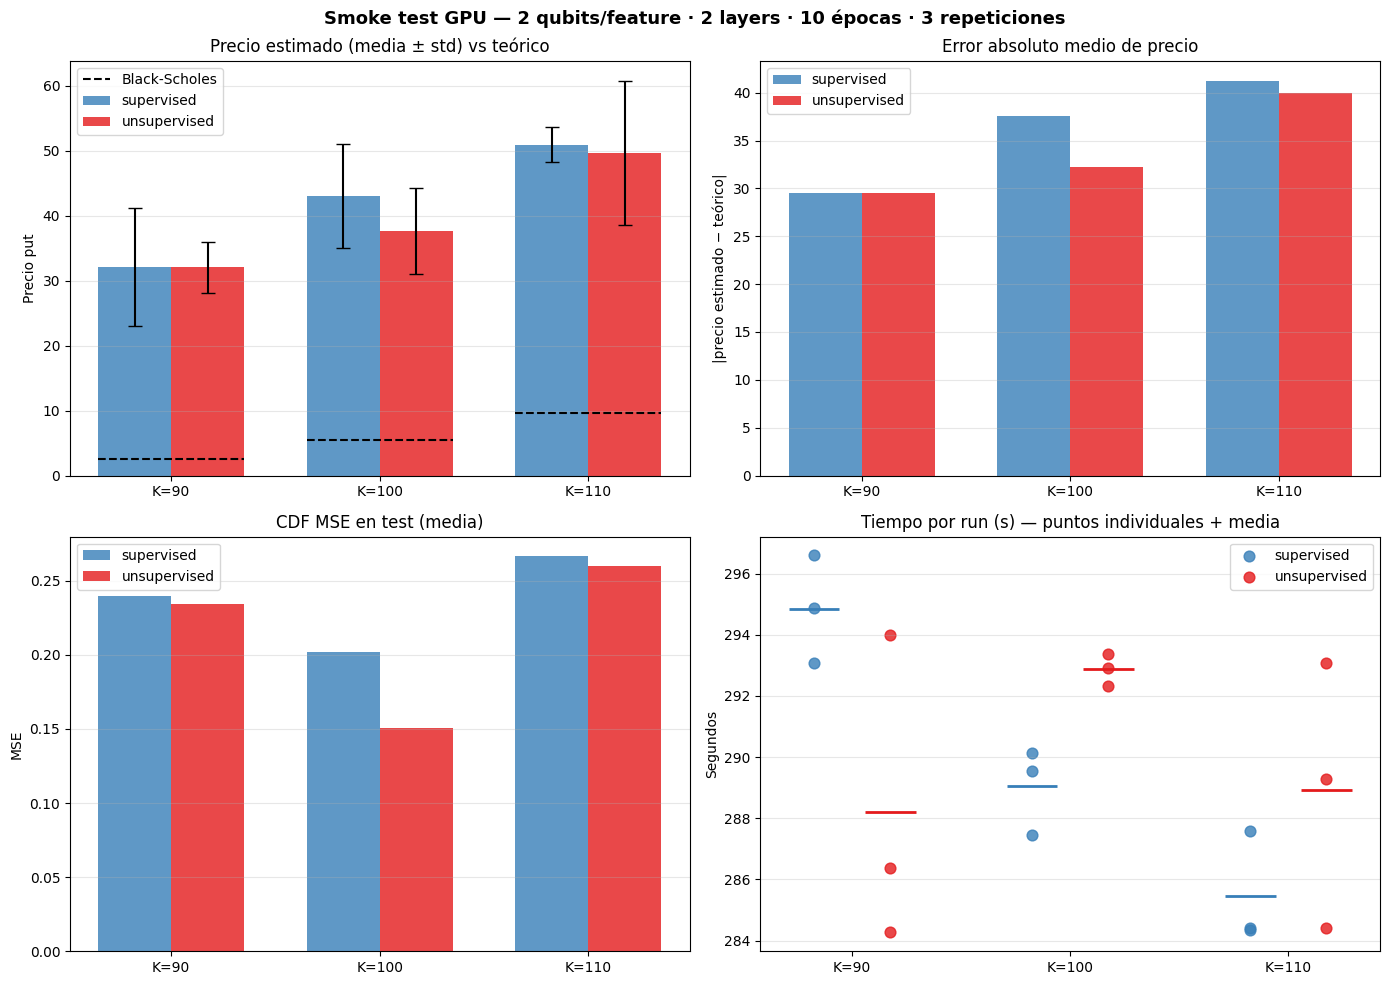

: 

In [13]:
COLORS = {"supervised": "#377eb8", "unsupervised": "#e41a1c"}
MODES = ["supervised", "unsupervised"]
x_pos = np.arange(len(STRIKES))
bar_w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Smoke test GPU — {SMOKE_CFG['n_qubits_by_feature']} qubits/feature · "
    f"{SMOKE_CFG['n_layers']} layers · {SMOKE_CFG['epochs']} épocas · "
    f"{REPETITIONS} repeticiones",
    fontsize=13, fontweight="bold"
)

# ── Plot 1: Precio estimado vs teórico ────────────────────────────────────────
ax = axes[0, 0]
for i, mode in enumerate(MODES):
    df_m = summary[summary["mode"] == mode]
    offset = (i - 0.5) * bar_w
    ax.bar(
        x_pos + offset, df_m["mean_price"], bar_w,
        yerr=df_m["std_price"], capsize=5,
        color=COLORS[mode], alpha=0.8, label=mode,
    )
# Líneas teóricas
for j, K_ in enumerate(STRIKES):
    p_t = bs_put_price(S0, K_, r, sigma, T)
    ax.hlines(p_t, j - bar_w, j + bar_w, colors="black", linewidths=1.5,
              linestyles="--", label="Black-Scholes" if j == 0 else None)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"K={k}" for k in STRIKES])
ax.set_title("Precio estimado (media ± std) vs teórico")
ax.set_ylabel("Precio put")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ── Plot 2: Error absoluto medio ──────────────────────────────────────────────
ax = axes[0, 1]
for i, mode in enumerate(MODES):
    df_m = summary[summary["mode"] == mode]
    offset = (i - 0.5) * bar_w
    ax.bar(
        x_pos + offset, df_m["mean_error"], bar_w,
        color=COLORS[mode], alpha=0.8, label=mode,
    )
ax.set_xticks(x_pos)
ax.set_xticklabels([f"K={k}" for k in STRIKES])
ax.set_title("Error absoluto medio de precio")
ax.set_ylabel("|precio estimado − teórico|")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ── Plot 3: CDF MSE en test ───────────────────────────────────────────────────
ax = axes[1, 0]
for i, mode in enumerate(MODES):
    df_m = summary[summary["mode"] == mode]
    offset = (i - 0.5) * bar_w
    ax.bar(
        x_pos + offset, df_m["mean_cdf_mse"], bar_w,
        color=COLORS[mode], alpha=0.8, label=mode,
    )
ax.set_xticks(x_pos)
ax.set_xticklabels([f"K={k}" for k in STRIKES])
ax.set_title("CDF MSE en test (media)")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ── Plot 4: Tiempo de entrenamiento por run ───────────────────────────────────
ax = axes[1, 1]
for i, mode in enumerate(MODES):
    df_m = results_df[results_df["mode"] == mode]
    for j, K_ in enumerate(STRIKES):
        df_k = df_m[df_m["strike"] == K_]["seconds"].values
        xs = np.full(len(df_k), j + (i - 0.5) * bar_w)
        ax.scatter(xs, df_k, color=COLORS[mode], alpha=0.8, s=60,
                   label=mode if j == 0 else None)
        ax.hlines(df_k.mean(), j + (i - 0.5) * bar_w - bar_w / 3,
                  j + (i - 0.5) * bar_w + bar_w / 3,
                  colors=COLORS[mode], linewidths=2)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"K={k}" for k in STRIKES])
ax.set_title("Tiempo por run (s) — puntos individuales + media")
ax.set_ylabel("Segundos")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Visualizaciones -- Estilo articulo cientifico

Las siguientes graficas replican el estilo academico de las figuras del articulo.
Cada funcion acepta los datos producidos por el experimento principal.

### 11.1 Convergencia de precios (cf. Figuras 5 y 8)

Cuadricula de subgraficas: una por configuracion del circuito.
- Eje X: tamano del dataset (en el smoke test un unico punto, n=500)
- Eje Y: precio estimado con barras de error (std sobre repeticiones)
- Linea de puntos: precio analitico Black-Scholes por strike

In [ ]:
STRIKE_COLORS = {90: "#1f77b4", 100: "#ff7f0e", 110: "#2ca02c"}


def plot_price_convergence(
    results_df,
    strikes,
    theoretical_prices,
    mode_name,
    circuit_label="",
    size_col="dataset_size",
    ax=None,
    figsize=(7, 4.5),
):
    """
    Academic-style price convergence plot (Figures 5, 8 of the paper).

    Parameters
    ----------
    results_df         : DataFrame with columns [mode, strike, <size_col>, estimated_price]
    strikes            : list of strikes, e.g. [90, 100, 110]
    theoretical_prices : dict {K: analytical_price}
    mode_name          : "supervised" or "unsupervised"
    circuit_label      : LaTeX string for subplot title, e.g. r"2 \\times 2"
    size_col           : x-axis column (default "dataset_size")
    """
    df = results_df[results_df["mode"] == mode_name].copy()
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    for K_ in strikes:
        color = STRIKE_COLORS[int(K_)]
        agg = (
            df[df["strike"] == K_]
            .groupby(size_col, sort=True)["estimated_price"]
            .agg(["mean", "std"])
            .reset_index()
        )
        agg["std"] = agg["std"].fillna(0.0)
        ax.errorbar(
            agg[size_col], agg["mean"],
            yerr=agg["std"],
            fmt="o-", color=color, linewidth=0.9, markersize=5,
            capsize=3, label=f"$K={int(K_)}$",
        )
        ax.axhline(
            theoretical_prices[int(K_)], color=color,
            linestyle=":", linewidth=1.3, alpha=0.85,
        )

    if len(df[size_col].unique()) > 1:
        ax.set_xscale("log")
    ax.set_xlabel("Size of the dataset $(n)$", fontsize=10)
    ax.set_ylabel("Price", fontsize=10)
    ax.set_ylim(0, 12)
    title = f"Estimated prices for (${circuit_label}$)" if circuit_label else mode_name
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.25, linestyle="--")
    if standalone:
        plt.tight_layout()
        plt.show()
    return ax


# Demo con datos del smoke test
# (un unico tamano de dataset; convergencia completa en notebooks 01/02)
demo_df = results_df.copy()
demo_df["dataset_size"] = SMOKE_CFG["n_train"]

theor = {int(K_): float(bs_put_price(S0, K_, r, sigma, T)) for K_ in STRIKES}
circuit_label = f"{SMOKE_CFG['n_qubits_by_feature']} \\times {SMOKE_CFG['n_layers']}"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, mode in zip(axes, ["supervised", "unsupervised"]):
    plot_price_convergence(
        demo_df, STRIKES, theor,
        mode_name=mode,
        circuit_label=circuit_label,
        size_col="dataset_size",
        ax=ax,
    )
    ax.set_title(f"Estimated prices -- {mode} (${circuit_label}$)", fontsize=10)

plt.suptitle("Price convergence (smoke test, single dataset size)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


: 

### 11.2 Ajuste de distribuciones -- CDF (cf. Figuras 6 y 7)

Panel por arquitectura cuantica:
- **Real Function**: CDF teorica Black-Scholes (linea roja)
- **Prediction P_ij**: predicciones por semilla (lineas grises semitransparentes)
- **Prediction Median**: mediana sobre todas las semillas (linea negra gruesa)

In [ ]:
def plot_distribution_fitting(
    weights_by_label,
    workflow_cfg_by_label,
    true_cdf_fn,
    domain=(-2 * np.pi, 2 * np.pi),
    n_grid=300,
    figsize=None,
):
    """
    Distribution fitting plot (Figures 6, 7 of the paper).

    Parameters
    ----------
    weights_by_label      : dict {"label": [w1, w2, ...]} -- one list per architecture
    workflow_cfg_by_label : dict {"label": workflow_cfg}
    true_cdf_fn           : callable(u_array) -> CDF values on domain
    """
    labels = list(weights_by_label.keys())
    n_panels = len(labels)
    if figsize is None:
        figsize = (4.5 * n_panels + 0.5, 4.2)

    fig, axes = plt.subplots(1, n_panels, figsize=figsize, sharey=True)
    if n_panels == 1:
        axes = [axes]

    u_grid = np.linspace(domain[0], domain[1], n_grid).reshape(-1, 1)
    u_flat = u_grid[:, 0]
    y_true = true_cdf_fn(u_flat)

    panel_ids = ["(a)", "(b)", "(c)", "(d)"]
    for ax, label, pid in zip(axes, labels, panel_ids):
        wf_cfg = workflow_cfg_by_label[label]
        all_preds = []
        for i, w in enumerate(weights_by_label[label]):
            pred = (
                workflow_for_cdf(w, u_grid, dask_client=None, **wf_cfg)
                ["y_predict_cdf"].reshape(-1) + 0.5
            )
            all_preds.append(pred)
            lbl_scatter = "Prediction $P_{ij}$" if i == 0 else None
            ax.plot(u_flat, pred, color="#aaaaaa", linewidth=0.6,
                    alpha=0.35, label=lbl_scatter)

        if all_preds:
            median_pred = np.median(np.stack(all_preds, axis=0), axis=0)
            ax.plot(u_flat, median_pred, color="#111111", linewidth=2.0,
                    label="Prediction Median")

        ax.plot(u_flat, y_true, color="#d62728", linewidth=1.8,
                linestyle="-", label="Real Function")
        ax.set_xlabel("$u$", fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel("CDF", fontsize=10)
        ax.set_title(f"{pid} ${label}$", fontsize=10)
        ax.legend(fontsize=7.5, loc="upper left")
        ax.grid(True, alpha=0.2, linestyle="--")

    plt.tight_layout()
    plt.show()
    return fig, axes


# Demo: CDF proxy (sigmoide) sobre el dominio de entrenamiento
def _demo_cdf(u_array):
    return 1.0 / (1.0 + np.exp(-u_array / 2.0))


demo_weights_dist = {}
demo_wf_cfgs_dist = {}
for K_ in STRIKES:
    key = ("unsupervised", K_)
    if key in saved_weights:
        lbl = f"K={int(K_)}"
        demo_weights_dist[lbl] = saved_weights[key]
        demo_wf_cfgs_dist[lbl] = workflow_cfg

if demo_weights_dist:
    plot_distribution_fitting(
        demo_weights_dist,
        demo_wf_cfgs_dist,
        true_cdf_fn=_demo_cdf,
        domain=(TRAIN_INTERVAL[0], TRAIN_INTERVAL[1]),
    )
else:
    print("[INFO] Ejecuta primero el experimento principal (Seccion 7).")


: 

### 11.3 Fenomeno de Gibbs por intervalo de entrenamiento (cf. Figuras 2 y 3)

Compara entrenar en [-pi, pi] frente a [-2pi, 2pi]:
- **Panel (a)**: intervalo estrecho -> oscilaciones de Gibbs fuera del dominio
- **Panel (b)**: intervalo amplio -> curva suavizada

Las lineas verticales discontinuas marcan los limites del intervalo de entrenamiento.

In [ ]:
def plot_gibbs_phenomenon(
    weights_narrow,
    weights_wide,
    wf_cfg_narrow,
    wf_cfg_wide,
    narrow_interval=(-np.pi, np.pi),
    wide_interval=(-2 * np.pi, 2 * np.pi),
    eval_multiplier=1.6,
    n_eval=600,
    figsize=(12, 4),
):
    """
    Gibbs phenomenon illustration (Figures 2, 3 of the paper).

    Panel (a): training in [-pi, pi]  -> shows Gibbs oscillations beyond boundary
    Panel (b): training in [-2pi, 2pi] -> smooth prediction
    """
    a_w, b_w = wide_interval
    eval_range = (a_w * eval_multiplier, b_w * eval_multiplier)
    u_eval = np.linspace(eval_range[0], eval_range[1], n_eval).reshape(-1, 1)
    u_flat = u_eval[:, 0]

    configs = [
        (weights_narrow, wf_cfg_narrow, narrow_interval,
         r"Training in $[-\pi,\pi]$"),
        (weights_wide, wf_cfg_wide, wide_interval,
         r"Training in $[-2\pi,2\pi]$"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, (weights, wf_cfg, interval, title) in zip(axes, configs):
        pred = (
            workflow_for_cdf(weights, u_eval, dask_client=None, **wf_cfg)
            ["y_predict_cdf"].reshape(-1) + 0.5
        )
        ax.plot(u_flat, pred, color="#1a3a6b", linewidth=1.5, label="Prediction")
        ax.axvline(interval[0], color="#d62728", linestyle="--",
                   linewidth=1.3, label="Training boundary (left)")
        ax.axvline(interval[1], color="#2ca02c", linestyle="--",
                   linewidth=1.3, label="Training boundary (right)")
        ax.set_xlabel("$u$", fontsize=10)
        ax.set_ylabel("CDF", fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2, linestyle="--")

    plt.tight_layout()
    plt.show()
    return fig, axes


def _quick_train_gibbs(train_interval, n_samples=400, n_epochs=25, seed=99):
    """Train a minimal model on a given interval for Gibbs demonstration."""
    a, b = train_interval
    bf, sf = normalize_data([a], [b], [-np.pi], [np.pi])
    cfn, wn, fn = hardware_efficient_ansatz(
        features_number=1,
        n_qubits_by_feature=SMOKE_CFG["n_qubits_by_feature"],
        n_layers=SMOKE_CFG["n_layers"],
        base_frecuency=list(bf),
        shift_feature=list(sf),
    )
    wf = {
        "circuit_fn": cfn, "weights_names": wn, "features_names": fn,
        "torch_device": TORCH_DEVICE,
        "minval": [a], "maxval": [b], "points": 40,
    }
    _, u_all, _, _ = simulate_black_scholes_data_rescaled(
        S0_=S0, r_=r, T_=T, sigma_=sigma, K_=100.0, n_points=n_samples, seed=seed
    )
    # Rescale from [-pi, pi] to [a, b]
    u_rescaled = np.clip(u_all * (b - a) / (2.0 * np.pi), a, b)
    y = empirical_cdf(u_rescaled).reshape(-1, 1) - 0.5

    def _loss(w):
        return qdml_loss_workflow(
            w, u_rescaled, y, dask_client=None, loss_weights=[0.9, 0.1], **wf)

    def _inner(w_, x_, y_):
        return qdml_loss_workflow(
            w_, x_, y_, dask_client=None, loss_weights=[0.9, 0.1], **wf)

    def _grad(w, x, y_):
        return torch_gradient(w, x, y_, _inner)

    return adam_optimizer_loop(
        weights_dict=init_weights(wn),
        loss_function=_loss, metric_function=None, gradient_function=_grad,
        batch_generator=[(u_rescaled, y)], initial_time=0,
        epochs=n_epochs, learning_rate=0.05, beta1=0.9, beta2=0.999,
        tolerance=1e-8, n_counts_tolerance=999, print_step=n_epochs + 1,
    ), wf


print("Entrenando modelo en [-pi, pi] para demo Gibbs...")
w_narrow, wf_narrow = _quick_train_gibbs((-np.pi, np.pi))
print("Entrenando modelo en [-2pi, 2pi] para demo Gibbs...")
w_wide, wf_wide = _quick_train_gibbs((-2 * np.pi, 2 * np.pi))
print("Listo.")

plot_gibbs_phenomenon(
    weights_narrow=w_narrow,
    weights_wide=w_wide,
    wf_cfg_narrow=wf_narrow,
    wf_cfg_wide=wf_wide,
)


: 

---

## 10. Checklist final

| Check | Esperado |
|-------|----------|
| `nvidia-smi` imprime GPU | Sin errores |
| `TORCH_DEVICE = cuda` | `cuda` (no `cpu`) |
| Loop completo sin excepciones | 18 runs (2 modos × 3 strikes × 3 reps) |
| Precios estimados | Valores finitos (no NaN) |
| Gráficas renderizadas | 4 subplots visibles |

Si todos los checks pasan, el repositorio está listo para ejecutarse en el servidor de GPU dedicado.